# Examen Tema 3

Se tendrá en cuenta:
- La calidad y eficiencia del código
- Ausencia de warnings y errores
- La calidad visual de los gráficos
- Interpretaciones de los resultados


# Importación de librerías y datos

Son datos de jugadores de la Premier League. Solamente hay datos de 3 equipos:
- **MUN**: Manchester United
- **CHE**: Chelsea
- **LIV**: Liverpool


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('EPL_Soccer.csv')

print('Tamaño del dataframe:', df.shape)
display(df.head())


Tamaño del dataframe: (202, 13)


,PlayerName,Club,DistanceCovered(InKms),Goals,MinutestoGoalRatio,ShotsPerGame,AgentCharges,BMI,Cost,PreviousClubCost,Height,Weight,Score
0,"Braund, Mr. Owen Harris",MUN,3.96,7.5,37.5,12.3,60,20.56,109.1,63.32,195.9,78.9,19.75
1,"Allen, Mr. William Henry",MUN,4.41,8.3,38.2,12.7,68,20.67,102.8,58.55,189.7,74.4,21.30
2,"Moran, Mr. James",MUN,4.14,5.0,36.4,11.6,21,21.86,104.6,55.36,177.8,69.1,19.88
3,"McCarthy, Mr. Timothy J",MUN,4.11,5.3,37.3,12.6,69,21.88,126.4,57.18,185.0,74.9,23.66
4,"Palsson, Master. Gosta Leonard",MUN,4.45,6.8,41.5,14.0,29,18.96,80.3,53.20,184.6,64.6,17.64


### Significado de cada columna

- **PlayerName**: Nombre del jugador
- **Club**: Club del jugador
- **DistanceCovered(InKms)**: Kilómetros promedio recorridos por partido
- **Goals**: Promedio de goles por partido
- **MinutestoGoalRatio**: Minutos por gol
- **ShotsPerGame**: Tiros promedio por partido
- **AgentCharges**: Honorarios del agente
- **BMI**: Índice de masa corporal
- **Cost**: Coste del fichaje
- **PreviousClubCost**: Coste anterior del club de procedencia
- **Height**: Altura
- **Weight**: Peso
- **Score**: Puntuación de rendimiento


## Ejercicio 1. Tartas (1 punto)

Crea un gráfico de tartas para visualizar la distribución del gasto en fichajes de cada equipo (columna **Cost**). Se debe visualizar el % de gasto dentro de cada porción con 1 decimal.


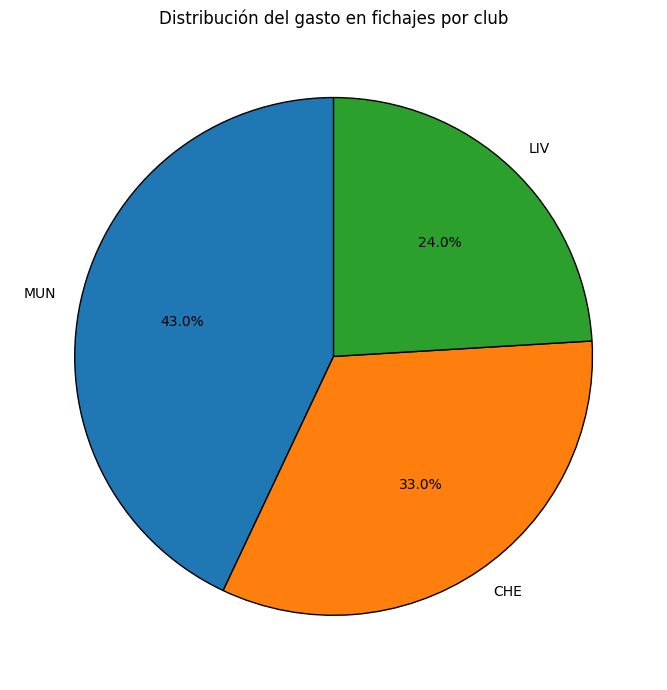

In [2]:
gasto_fichajes = df.groupby('Club')['Cost'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 7))
plt.pie(
    gasto_fichajes.values,
    labels=gasto_fichajes.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
plt.title('Distribución del gasto en fichajes por club')
plt.tight_layout()
plt.show()


## Ejercicio 2. Diagrama de barras (1.5 puntos)

- Muestra en un diagrama de barras la **media** de distancia corrida `DistanceCovered(InKms)` por cada club.
- El eje X es el nombre del club.
- El eje Y es la media de la distancia corrida por los jugadores de cada club.
- Pinta el borde de las barras de negro.
- Crea un grid de líneas horizontales.


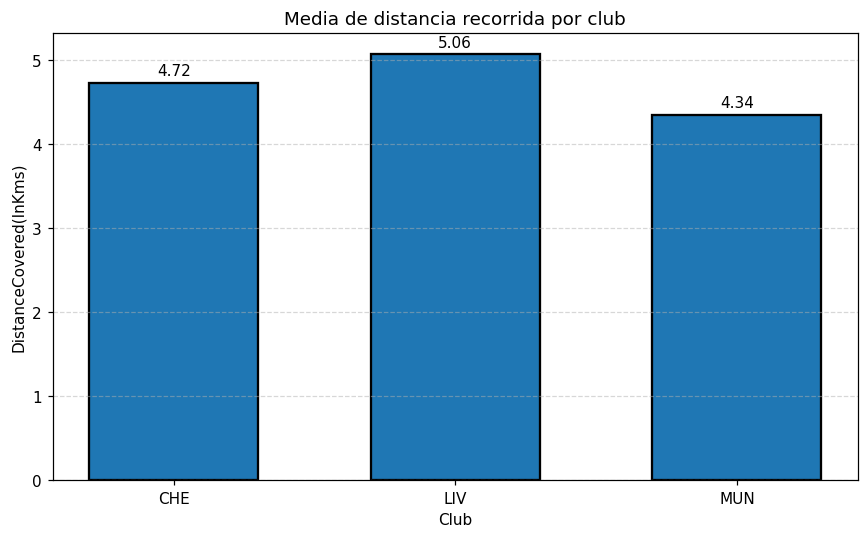

Club
CHE    4.72
LIV    5.06
MUN    4.34
Name: DistanceCovered(InKms), dtype: float64

In [3]:
distancia_media = df.groupby('Club')['DistanceCovered(InKms)'].mean().round(2)

fig, ax = plt.subplots(figsize=(8, 5), dpi=110)

barras = ax.bar(
    distancia_media.index,
    distancia_media.values,
    edgecolor='black',
    linewidth=1.5,
    width=0.6
)

ax.bar_label(barras, fmt='%.2f', padding=3)
ax.set_title('Media de distancia recorrida por club')
ax.set_xlabel('Club')
ax.set_ylabel('DistanceCovered(InKms)')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

distancia_media


## Ejercicio 3. Histograma (2.5 puntos)

### Gráfica

Crea un histograma con el **Score**. El histograma debe mostrar en el eje Y el número de jugadores que entran dentro de cada rango.

- Se deben crear **15 barras**.
- Añade un `grid` solamente de líneas en el eje y de estilo línea discontinua `--` y semitransparente.
- Añade a cada barra un borde negro.
- Añade líneas verticales marcando la **media** y **mediana**, de estilo `:`, cada una de un color diferente, y que se vea en la leyenda.
- Añade una zona sombreada que represente **una desviación típica alrededor de la media**.
- Indica brevemente la forma de la distribución.


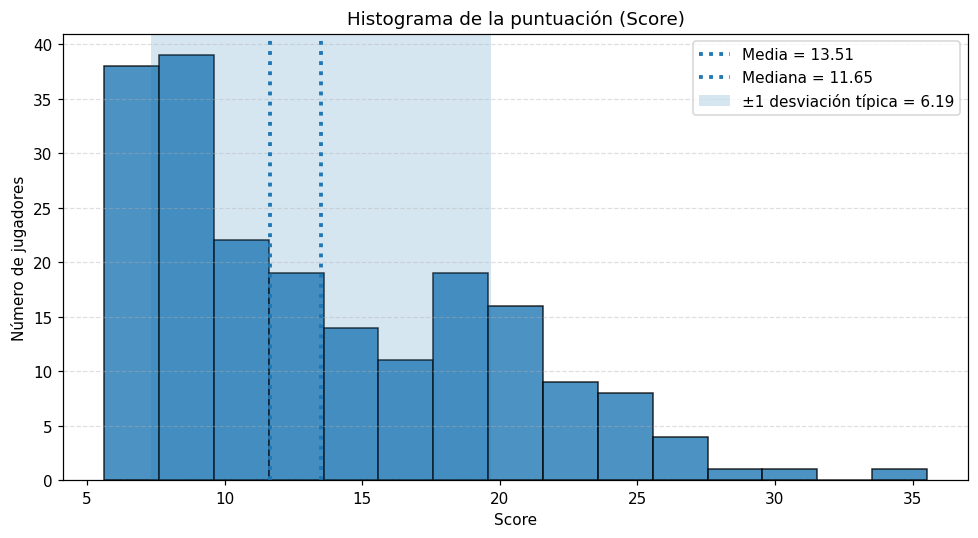

Media: 13.51
Mediana: 11.65
Desviación típica: 6.19
Interpretación: la distribución presenta sesgo positivo (cola hacia la derecha).


In [4]:
score = df['Score']

media = score.mean()
mediana = score.median()
desv_tipica = score.std()

fig, ax = plt.subplots(figsize=(9, 5), dpi=110)

ax.hist(score, bins=15, edgecolor='black', alpha=0.8)
ax.axvline(media, linestyle=':', linewidth=2.5, label=f'Media = {media:.2f}')
ax.axvline(mediana, linestyle=':', linewidth=2.5, label=f'Mediana = {mediana:.2f}')
ax.axvspan(media - desv_tipica, media + desv_tipica, alpha=0.18, label=f'±1 desviación típica = {desv_tipica:.2f}')

ax.set_title('Histograma de la puntuación (Score)')
ax.set_xlabel('Score')
ax.set_ylabel('Número de jugadores')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación típica: {desv_tipica:.2f}")

if media > mediana:
    print('Interpretación: la distribución presenta sesgo positivo (cola hacia la derecha).')
elif media < mediana:
    print('Interpretación: la distribución presenta sesgo negativo (cola hacia la izquierda).')
else:
    print('Interpretación: la distribución es aproximadamente simétrica.')


## Ejercicio 4. Nube de puntos (2.5 puntos)

### 1. Correlación
- Muestra la correlación entre todas las variables numéricas.
- ¿Qué 4 variables tienen más correlación (positiva o negativa) con **Score**?

### 2. Gráfica
- Muestra en una figura de **2x2** nubes de puntos de **Score** con cada variable de la respuesta anterior. `Score` en el eje Y.
- Muestra el **centro de la distribución** con un `+` en otro color.
- Muestra un **cuadro de texto** con el texto `Pearson r = valor`.


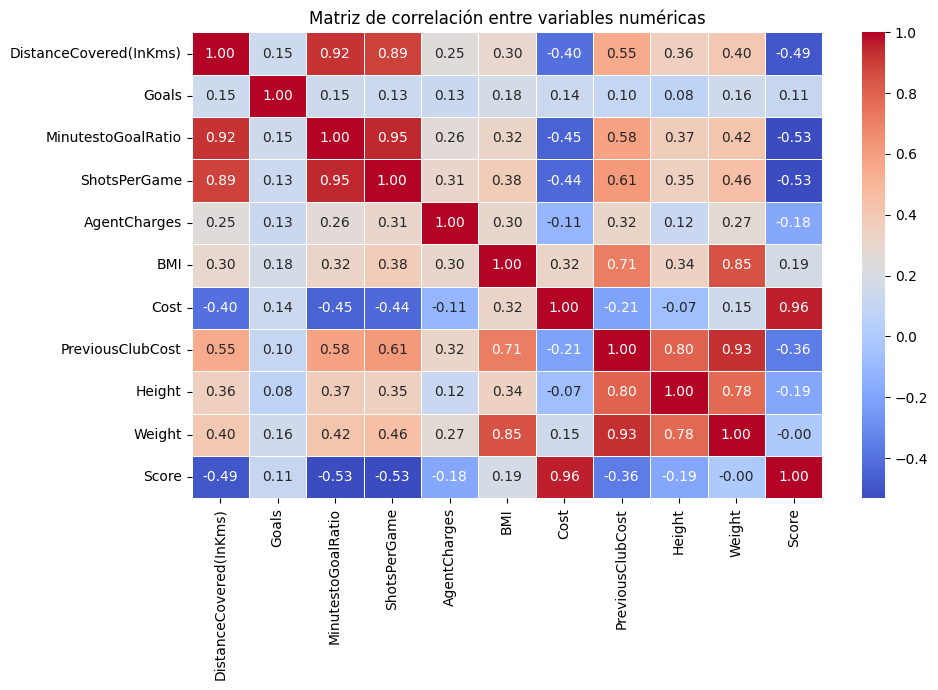

Las 4 variables con mayor correlación (positiva o negativa) con Score son:


,Correlación con Score
Cost,0.963017
MinutestoGoalRatio,-0.532449
ShotsPerGame,-0.531522
DistanceCovered(InKms),-0.493512


In [5]:
numericas_df = df.select_dtypes(include='number')
corr_matrix = numericas_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

corr_score = corr_matrix['Score'].drop('Score').sort_values(key=lambda s: s.abs(), ascending=False)
top4 = corr_score.head(4)

print('Las 4 variables con mayor correlación (positiva o negativa) con Score son:')
display(top4.to_frame(name='Correlación con Score'))


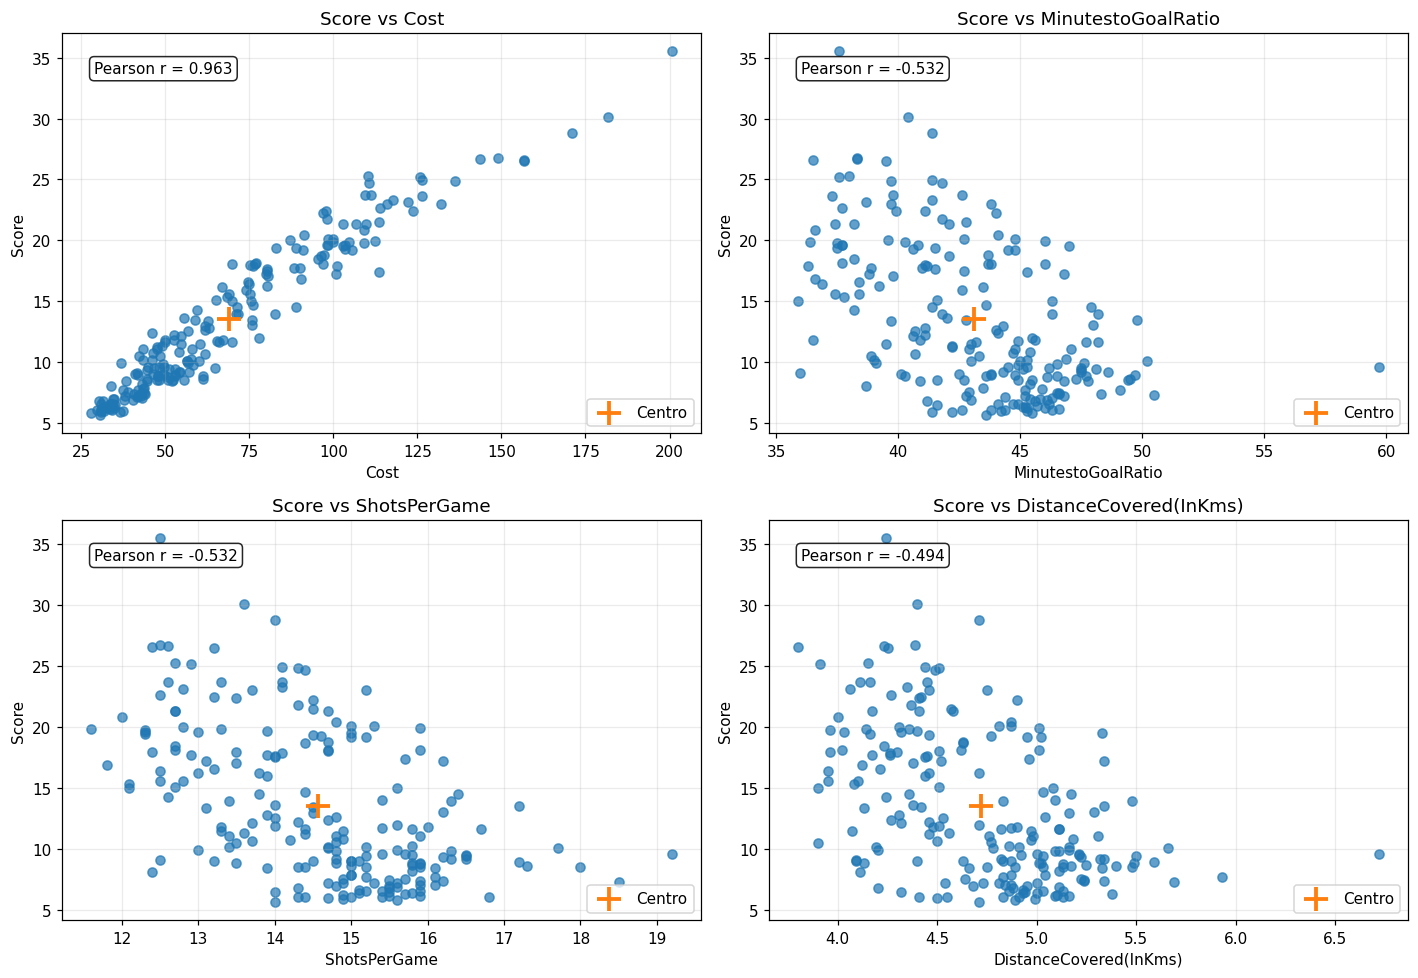

In [6]:
variables_top4 = top4.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=110)
axes = axes.flatten()

for ax, variable in zip(axes, variables_top4):
    x = df[variable]
    y = df['Score']
    r = x.corr(y)

    ax.scatter(x, y, alpha=0.7)
    ax.scatter(x.mean(), y.mean(), marker='+', s=250, linewidths=2.5, label='Centro')
    ax.text(
        0.05, 0.93, f'Pearson r = {r:.3f}',
        transform=ax.transAxes,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
    )
    ax.set_title(f'Score vs {variable}')
    ax.set_xlabel(variable)
    ax.set_ylabel('Score')
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


## Ejercicio 5. Boxplot (2.5 puntos)

### Gráfica
- Crea un **boxplot vertical** donde el eje Y sea `Score` y el eje X el `Club`.
- Pinta una línea de estilo `--` con la **media** de puntuación total, visible en la leyenda.

### Justificaciones y otros
- Calcula el **IQR** de cada box y los **límites** para considerar outliers de cada equipo.
- Muestra los **jugadores outliers** de cada equipo.
- Compara las cajas: qué equipo tiene mayor mediana, dónde hay mayor variabilidad y si hay presencia de outliers.


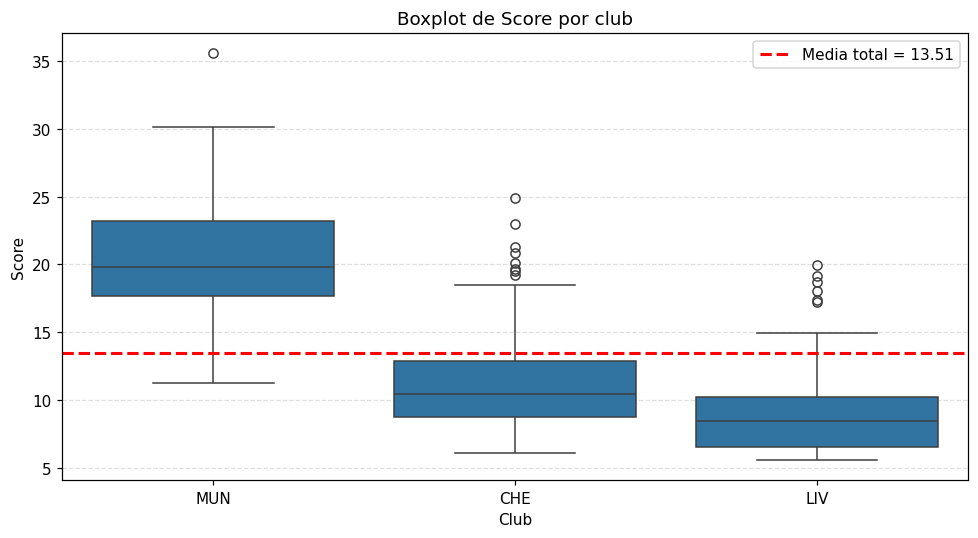

In [7]:
media_total = df['Score'].mean()

fig, ax = plt.subplots(figsize=(9, 5), dpi=110)
sns.boxplot(data=df, x='Club', y='Score', ax=ax)
ax.axhline(media_total, color='red', linestyle='--', linewidth=2, label=f'Media total = {media_total:.2f}')
ax.set_title('Boxplot de Score por club')
ax.set_xlabel('Club')
ax.set_ylabel('Score')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()


In [8]:
resumen = []
outliers_detalle = []

for club, datos_club in df.groupby('Club'):
    q1 = datos_club['Score'].quantile(0.25)
    q3 = datos_club['Score'].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = datos_club[
        (datos_club['Score'] < limite_inferior) |
        (datos_club['Score'] > limite_superior)
    ][['PlayerName', 'Score']].sort_values('Score', ascending=False)

    resumen.append({
        'Club': club,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Límite inferior': limite_inferior,
        'Límite superior': limite_superior,
        'Media': datos_club['Score'].mean(),
        'Mediana': datos_club['Score'].median(),
        'Desv. típica': datos_club['Score'].std(),
        'Nº outliers': len(outliers)
    })

    if outliers.empty:
        outliers_detalle.append(pd.DataFrame([{
            'Club': club,
            'PlayerName': 'Sin outliers',
            'Score': None
        }]))
    else:
        outliers = outliers.copy()
        outliers.insert(0, 'Club', club)
        outliers_detalle.append(outliers)

resumen_df = pd.DataFrame(resumen).round(2)
outliers_df = pd.concat(outliers_detalle, ignore_index=True)

display(resumen_df)
display(outliers_df)


,Club,Q1,Q3,IQR,Límite inferior,Límite superior,Media,Mediana,Desv. típica,Nº outliers
0,CHE,8.80,12.88,4.09,2.66,19.02,11.61,10.50,4.19,8
1,LIV,6.56,10.25,3.69,1.02,15.78,9.42,8.51,3.76,6
2,MUN,17.68,23.20,5.53,9.38,31.50,20.52,19.83,4.51,1


,Club,PlayerName,Score
0,CHE,"Connors, Mr. Patrick",24.88
1,CHE,"Hickman, Mr. Stanley George",23.01
2,CHE,"Barton, Mr. David John",21.30
3,CHE,"Burke, Mr. Jeremiah",20.86
4,CHE,"Pekoniemi, Mr. Edvard",20.10
5,CHE,"Andrew, Mr. Edgardo Samuel",19.64
6,CHE,"Baxter, Mr. Quigg Edmond",19.51
7,CHE,"Turpin, Mr. William John Robert",19.26
8,LIV,"Minahan, Dr. William Edward",19.94
9,LIV,"Smith, Mr. Richard William",19.17


### Comparación de las cajas

- **Mayor mediana**: se obtiene observando la columna de mediana del resumen anterior.
- **Mayor variabilidad**: se puede justificar tanto por el **IQR** como por la **desviación típica**; el equipo con valores más altos presenta mayor dispersión.
- **Outliers**: se identifican con la regla de Tukey, usando los límites `Q1 - 1.5·IQR` y `Q3 + 1.5·IQR`.

La justificación final debe apoyarse en los valores mostrados en las tablas anteriores.
